# Test CNN LSTM Attention

## Setup Library

In [1]:
# ================= PATH SETUP =================
import os
import sys
sys.path.append(os.path.abspath(".."))

# ================= STANDARD LIB ================
from collections import deque, Counter

# ================= THIRD PARTY =================
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image
import torchvision.transforms as transforms
from sklearn.metrics import classification_report

# ================= LOCAL MODULE =================
from utils.dataloader import get_dataloader, get_transforms
from utils.evaluate import evaluate
from models.cnn_lstm import CNN_LSTM

# ===== PATH =====
sys.path.append(os.path.abspath(".."))
BASE_DIR = os.path.abspath("..")

## Get Latest CNN Model Function

In [2]:
def get_latest_model(log_dir):
    runs = [
        d for d in os.listdir(log_dir)
        if d.startswith("run_") and os.path.isdir(os.path.join(log_dir, d))
    ]

    if len(runs) == 0:
        raise ValueError("No run folders found!")

    runs = sorted(runs)  # urut berdasarkan timestamp
    latest_run = runs[-1]

    model_path = os.path.join(log_dir, latest_run, "best_model.pth")

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model not found: {model_path}")

    return model_path

## Load Dataset and Model

In [3]:
test_path = os.path.join(BASE_DIR, "data/WLBisindo/split/test")

BASE_DIR = os.path.abspath("..")

log_dir = os.path.join(BASE_DIR, "outputs/logs/cnn_lstm")

MODEL_PATH = get_latest_model(log_dir)

print("Using model:", MODEL_PATH)

# ===== LOAD DATA =====
_, val_transform = get_transforms()

test_loader, test_dataset = get_dataloader(
    test_path,
    transform=val_transform,
    use_weighted_sampler=False
)

NUM_CLASSES = len(test_dataset.label_map)

# ===== LOAD MODEL =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_LSTM(num_classes=NUM_CLASSES).to(device)
state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state_dict)

model.eval()
print("Model loaded!")

# ===== EVALUATION =====
metrics = evaluate(
    model,
    test_loader,
    device,
    save_path=os.path.join(os.path.dirname(MODEL_PATH), "test_eval.json"),
    model_name="CNN_LSTM_TEST"
)

print("Metrics:", metrics)

# ===== PREDICTION =====
y_true = []
y_pred = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Done inference!")

# ===== REPORT =====
print(classification_report(y_true, y_pred))

Using model: d:\Softwares\UnityGithub\SignComparisonCNN\outputs/logs/cnn_lstm\run_20260415_195341\best_model.pth
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\ASUS A409UJ/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 51.9MB/s]


Model loaded!


d:\Softwares\Anaconda\envs\deep_learning\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Evaluation Metrics:
accuracy: 0.8924
precision: 0.9060
recall: 0.8926
f1: 0.8913
hamming_loss: 0.1076
Experiment logged to: d:\Softwares\UnityGithub\SignComparisonCNN\outputs/metrics\experiments.csv
Metrics: {'accuracy': 0.8923766816143498, 'precision': 0.9059580176767676, 'recall': 0.8925595238095239, 'f1': 0.8913414914334032, 'hamming_loss': 0.10762331838565023}


d:\Softwares\Anaconda\envs\deep_learning\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Done inference!
              precision    recall  f1-score   support

           0       1.00      0.75      0.86         8
           1       0.80      1.00      0.89         4
           2       1.00      0.88      0.93         8
           3       1.00      0.88      0.93         8
           4       1.00      1.00      1.00         6
           5       1.00      0.88      0.93         8
           6       1.00      1.00      1.00         8
           7       0.70      1.00      0.82         7
           8       1.00      0.75      0.86         4
           9       0.75      0.75      0.75         8
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00         8
          12       0.89      1.00      0.94         8
          13       0.80      1.00      0.89         4
          14       1.00      0.80      0.89         5
          15       1.00      1.00      1.00         7
          16       1.00      0.83      0.91         6
          1

## Model Evaluation Visual Test

d:\Softwares\Anaconda\envs\deep_learning\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


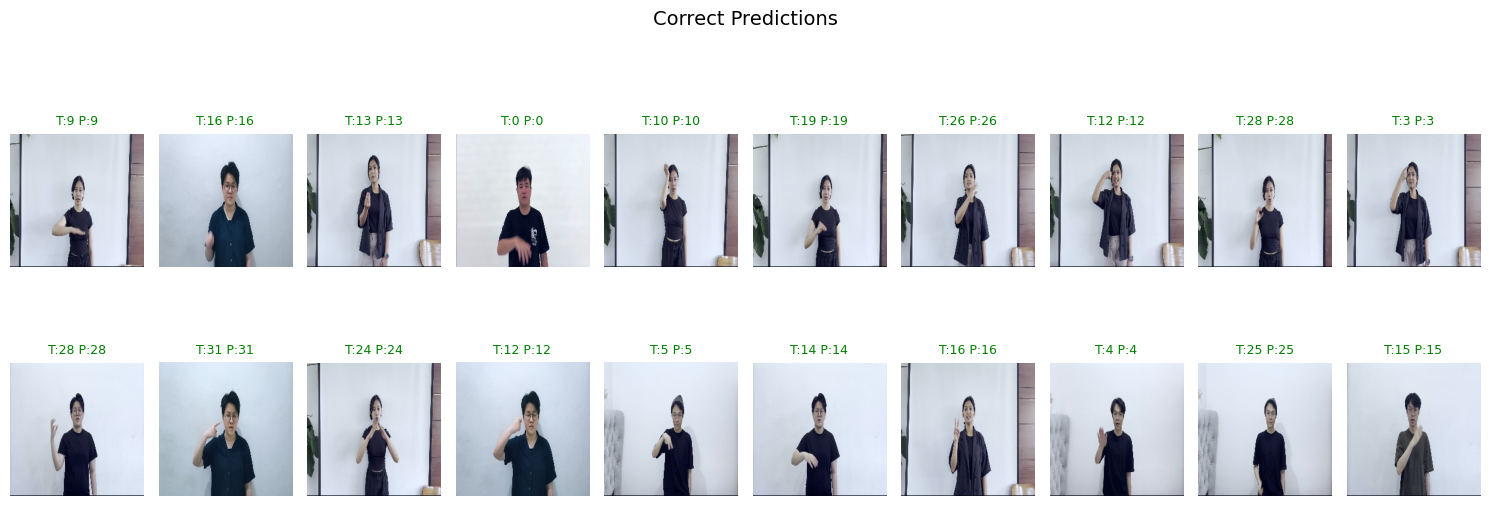

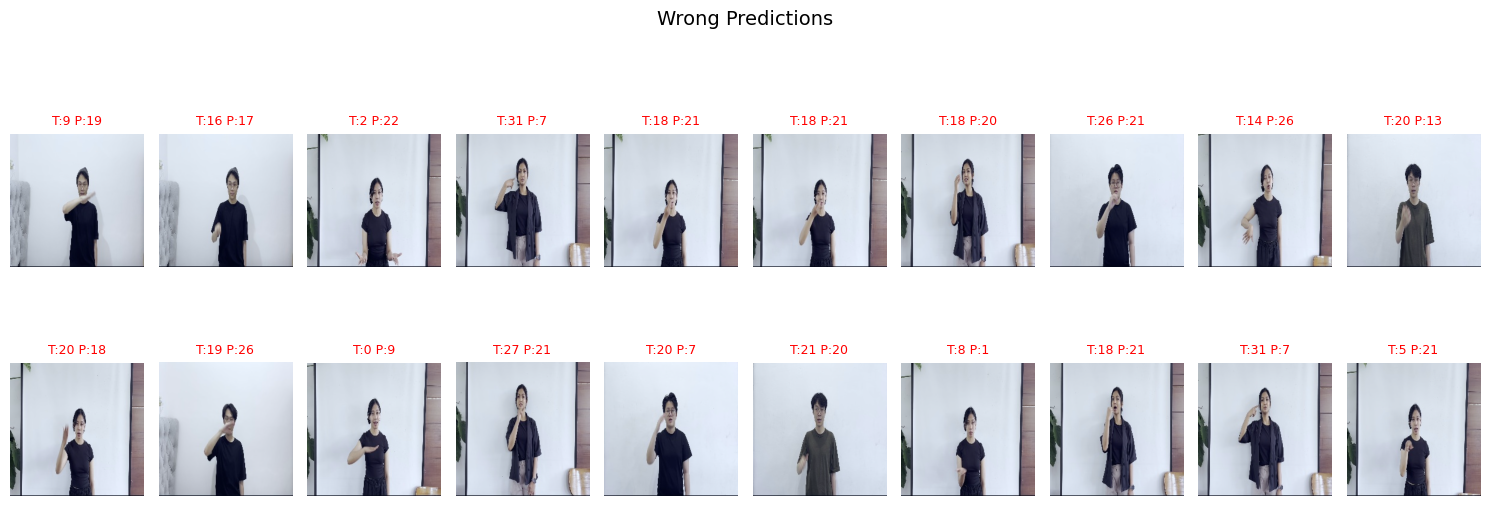

In [4]:
correct_samples = []
wrong_samples = []

model.eval()

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        for i in range(len(y)):
            sample = (x[i].cpu(), y[i].item(), preds[i].item())

            if preds[i] == y[i] and len(correct_samples) < 20:
                correct_samples.append(sample)

            elif preds[i] != y[i] and len(wrong_samples) < 20:
                wrong_samples.append(sample)

        if len(correct_samples) >= 20 and len(wrong_samples) >= 20:
            break

plt.style.use('default')

def plot_samples(samples, title):
    fig = plt.figure(figsize=(15,6), facecolor='white')
    fig.suptitle(title, fontsize=14)

    for i, (frames, true, pred) in enumerate(samples):
        img = frames[len(frames)//2]  # frame tengah

        # ambil 3 channel (RGB)
        img = img[:3]
        img = img.permute(1, 2, 0).numpy()

        # normalize biar aman
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        ax = plt.subplot(2, 10, i+1)
        ax.set_facecolor('white')

        # warna title
        color = "green" if true == pred else "red"

        ax.imshow(img)
        ax.set_title(f"T:{true} P:{pred}", color=color, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

plot_samples(correct_samples, "Correct Predictions")
plot_samples(wrong_samples, "Wrong Predictions")

## Model Global Confusion

=== GLOBAL CONFUSION (SIMPLIFIED) ===
TP (Correct) : 199
FP (Wrong)   : 24
FN           : 24
TN           : 0


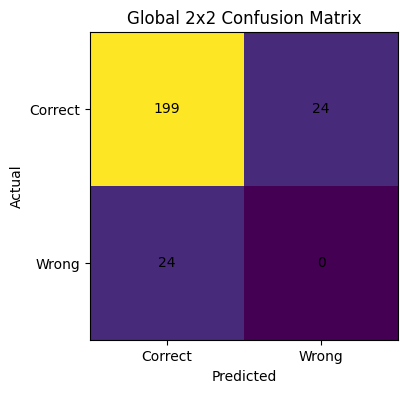

In [5]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# BENAR vs SALAH
tp = np.sum(y_true == y_pred)
fp = np.sum(y_true != y_pred)

fn = fp
tn = 0

print("=== GLOBAL CONFUSION (SIMPLIFIED) ===")
print(f"TP (Correct) : {tp}")
print(f"FP (Wrong)   : {fp}")
print(f"FN           : {fn}")
print(f"TN           : {tn}")

cm_2x2 = np.array([
    [tp, fn],
    [fp, tn]
])

plt.figure(figsize=(4,4))
plt.imshow(cm_2x2)

labels = ["Correct", "Wrong"]

plt.xticks([0,1], labels)
plt.yticks([0,1], labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Global 2x2 Confusion Matrix")

# isi angka
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_2x2[i, j],
                 ha="center", va="center")

plt.show()

In [6]:
# ===== PATH =====
sys.path.append(os.path.abspath(".."))
BASE_DIR = os.path.abspath("..")

# ================= CONFIG =================
SEQ_LEN = 20
PRED_BUFFER_SIZE = 10
CONF_THRESHOLD = 0.3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================= LABEL =================
train_dir = os.path.join(BASE_DIR, "data/WLBisindo/split/train")
labels = sorted(os.listdir(train_dir))
label_map = {i: label for i, label in enumerate(labels)}

NUM_CLASSES = len(label_map)

# ================= TRANSFORM =================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ================= MODEL =================
model = CNN_LSTM(num_classes=NUM_CLASSES)

state_dict = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True)
model.load_state_dict(state_dict)

model.to(DEVICE)
model.eval()

print("Model loaded (6-channel)")

# ================= BUFFER =================
frame_buffer = deque(maxlen=SEQ_LEN)
pred_buffer = deque(maxlen=PRED_BUFFER_SIZE)

prev_img = None  # 6 channel

# ================= WEBCAM =================
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Webcam error")
    exit()

print("Realtime CNN-LSTM 6CH (ESC to exit)")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    h, w, _ = frame.shape

    # ================= CENTER CROP =================
    cx, cy = w // 2, h // 2
    size = 300

    x1 = max(cx - size // 2, 0)
    y1 = max(cy - size // 2, 0)
    x2 = min(cx + size // 2, w)
    y2 = min(cy + size // 2, h)

    crop = frame[y1:y2, x1:x2]

    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # ================= PREPROCESS =================
    img = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(img)
    img = transform(img)  # (3, 224, 224)

    # ================= 6 CHANNEL =================
    if prev_img is None:
        combined = torch.cat([img, img], dim=0)  # (6, H, W)
    else:
        combined = torch.cat([prev_img, img], dim=0)

    prev_img = img
    frame_buffer.append(combined)

    label_text = "Collecting..."

    # ================= PREDICT =================
    if len(frame_buffer) == SEQ_LEN:

        input_tensor = torch.stack(list(frame_buffer))  # (20, 6, H, W)
        input_tensor = input_tensor.unsqueeze(0).to(DEVICE)  # (1, 20, 6, H, W)

        # DEBUG
        # print(input_tensor.shape)

        with torch.no_grad():
            outputs = model(input_tensor)
            probs = torch.softmax(outputs, dim=1)

            pred = torch.argmax(probs, dim=1).item()
            confidence = probs[0][pred].item()

        pred_buffer.append(pred)

        # smoothing
        final_pred = Counter(pred_buffer).most_common(1)[0][0]

        if confidence < CONF_THRESHOLD:
            label_text = "..."
        else:
            label_text = f"{label_map[final_pred]} ({confidence:.2f})"

    # ================= DISPLAY =================
    cv2.putText(frame, f"Pred: {label_text}", (20, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    cv2.imshow("Realtime BISINDO CNN-LSTM (6CH)", frame)

    key = cv2.waitKey(1) & 0xFF
    if key == 27:
        break

cap.release()
cv2.destroyAllWindows()

Model loaded (6-channel)
Realtime CNN-LSTM 6CH (ESC to exit)
